# Engine Start Audit

## Purpose

This notebook evaluates engine start events from sailplane IGC flight logs.

The analysis focuses on:

1. Understanding where and when engine starts occur.
2. Evaluating adherence to manufacturer guidelines.
3. Exploring factors associated with successful and unsuccessful engine operations.
4. Identifying variables that may be useful for engine-start classification models.

This analysis supports Success Criterion 1 of the capstone project.

# Load Dataset

In [67]:
import pandas as pd

df = pd.read_csv("../data/flights_final.csv", sep="\t")

print("Flights:", len(df))
print("Columns:", len(df.columns))

df.head()

Flights: 1740
Columns: 48


,index,Date (MM/DD/YYYY),File,Gtype,Flight Time,Start Time,End Time,Landing,Start_Alt (ft MSL),Max Altitude (ft MSL/ft AGL),...,distance_traveled_during_window (miles),terrain_label_at_first_engine_event,avg_speed_during_pre_event_window (knots),std_dev_speed_during_pre_event_window (knots),avg_speed_during_post_event_window (knots),engine_run_times (s),height_gain_loss (ft),terrain_elev_at_first_engine_event (ft),dynamic_AGL_at_first_engine_event (ft),Engine_Start_Above_1000ft
0,1,03/12/2016,2016-03-12-CNI-21J-01.IGC,LAK17BFES,3:11:16,171318,202434,HOME,114,4967[4840],...,5.074177,"Open Forest, Other",56.65,10.03,60.78,"[60, 420, 60, 480, 300, 180, 60, 60, 420, 480,...","[154, 210, -89, 318, -1105, 125, -105, -181, 1...",125.31,2551.86,True
1,2,06/25/2024,46PGA9D1.IGC,Ventus3M18m,4:31:17,184736,231853,HOME,3694,12821[8793],...,7.166436,Herbaceous vegetation,74.73,10.91,63.95,[600],[3743],4088.87,678.19,False
2,4,03/11/2014,43BG8FH1.IGC,Unknown,4:45:38,164720,213258,HOME,121,3795[3700],...,0.101798,Herbaceous vegetation,3.70,9.04,54.48,[120],[1266],112.02,-102.18,False
3,5,06/17/2018,2018-06-17-CNI-27X-01.IGC,DG80015,2:47:12,183443,212155,HOME,5009,14642[8914],...,0.125748,Herbaceous vegetation,9.55,6.67,49.24,[420],[2890],5003.28,-55.77,False
4,6,08/15/2023,2023-08-15-CNI-25N-01.IGC,ASH31mi,3:43:47,173705,212052,HOME,948,9192[7336],...,0.070698,Shrubs,11.64,10.89,56.23,[360],[2234],932.41,-72.83,False


In [46]:
print(df.columns.tolist())

['index', 'Date (MM/DD/YYYY)', 'File', 'Gtype', 'Flight Time', 'Start Time', 'End Time', 'Landing', 'Start_Alt (ft MSL)', 'Max Altitude (ft MSL/ft AGL)', 'Surface Height (ft MSL)', 'Pressure Altitude (ft MSL)', 'Offset (ft)', 'Sensor Info', 'ENL_Engine_Run_Start_Times', 'MOP_Engine_Run_Start_Times', 'RPM_Engine_Run_Start_Times', 'ENL_Engine_Run_Altitudes_MSL', 'MOP_Engine_Run_Altitudes_MSL', 'RPM_Engine_Run_Altitudes_MSL', 'ENL_Engine_Run_Altitudes_AGL', 'MOP_Engine_Run_Altitudes_AGL', 'RPM_Engine_Run_Altitudes_AGL', 'ENL_Noise_Registration_Times', 'MOP_Noise_Registration_Times', 'RPM_Noise_Registration_Times', 'ENL_Noise_Registration_Altitudes_AGL', 'MOP_Noise_Registration_Altitudes_AGL', 'RPM_Noise_Registration_Altitudes_AGL', 'first_event_time', 'event_type', 'event_sensor', 'first_event_datetime', 'window_start', 'window_end', 'altitude rate of change during pre-event window(ft/s)', 'steady_descent_during_pre_event_window', 'is_circling_during_pre_event_window', 'distance_traveled_

### Dataset Structure

The dataset contains numerical, categorical, and temporal variables describing engine-start events.

Variables include altitude measurements, timestamps, aircraft characteristics, engine sensor readings, and geographic information used for subsequent analysis.

# Data Quality Check

Before conducting analysis, the dataset was reviewed for completeness and consistency.

This step helps identify missing values, unexpected data types, and variables that may require additional cleaning.

In [68]:
df.isnull().sum().sort_values(ascending=False).head(15)

RPM_Noise_Registration_Altitudes_AGL    1740
RPM_Noise_Registration_Times            1740
RPM_Engine_Run_Start_Times              1713
RPM_Engine_Run_Altitudes_AGL            1713
RPM_Engine_Run_Altitudes_MSL            1713
MOP_Engine_Run_Start_Times              1572
MOP_Engine_Run_Altitudes_AGL            1572
MOP_Engine_Run_Altitudes_MSL            1572
MOP_Noise_Registration_Altitudes_AGL    1547
MOP_Noise_Registration_Times            1547
ENL_Engine_Run_Altitudes_AGL             195
ENL_Engine_Run_Start_Times               195
ENL_Engine_Run_Altitudes_MSL             195
ENL_Noise_Registration_Altitudes_AGL     115
ENL_Noise_Registration_Times             115
dtype: int64

### Interpretation

Several sensor-specific variables contain large numbers of missing values.

These missing values are expected because engine-start events are detected using different sensor systems (ENL, RPM, and MOP), and each sensor populates only its corresponding fields.

The core variables used in this analysis contain sufficient information for exploratory analysis and model development.

In [69]:
df.shape

(1740, 48)

In [70]:
df.duplicated().sum()

np.int64(0)

In [71]:
df["event_type"].value_counts()

event_type
Engine_Run_Start    1740
Name: count, dtype: int64

## Dataset Summary

The final dataset contains 1,740 engine start events and 48 variables describing engine behavior, location, altitude, timing, and sensor measurements.

A duplicate record check identified no duplicate observations, indicating strong data integrity.

All observations are classified as Engine_Run_Start events, confirming that the dataset aligns with the project's objective of analyzing glider engine start behavior.

In [47]:
key_cols = [
    "event_type",
    "event_sensor",
    "Landing",
    "steady_descent_during_pre_event_window",
    "is_circling_during_pre_event_window",
    "Engine_Start_Above_1000ft",
    "terrain_label_at_first_engine_event"
]

for col in key_cols:
    print("\n" + "="*60)
    print(col)
    print(df[col].value_counts(dropna=False).head(20))


event_type
event_type
Engine_Run_Start    1740
Name: count, dtype: int64

event_sensor
event_sensor
ENL    1545
MOP     168
RPM      27
Name: count, dtype: int64

Landing
Landing
HOME    1642
LOUT      98
Name: count, dtype: int64

steady_descent_during_pre_event_window
steady_descent_during_pre_event_window
Changing    1697
Steady        43
Name: count, dtype: int64

is_circling_during_pre_event_window
is_circling_during_pre_event_window
False    1614
True      126
Name: count, dtype: int64

Engine_Start_Above_1000ft
Engine_Start_Above_1000ft
False    1197
True      543
Name: count, dtype: int64

terrain_label_at_first_engine_event
terrain_label_at_first_engine_event
Herbaceous vegetation                  609
Open Forest, Other                     276
Shrubs                                 254
Agriculture                            203
Closed Forest, Other                   106
Closed Forest, Deciduous Broadleaf      94
Closed Forest, Evergreen Needleleaf     90
Bare/Sparse vegetatio

# Review Key Variables

This section examines important categorical variables used throughout the project.

# Summary Statistics

This section reviews the distribution of important numerical variables associated with engine-start events.

In [48]:
numeric_cols = [
    "dynamic_AGL_at_first_engine_event (ft)",
    "altitude rate of change during pre-event window(ft/s)",
    "distance_traveled_during_window (miles)",
    "avg_speed_during_pre_event_window (knots)",
    "avg_speed_during_post_event_window (knots)",
    "engine_run_times (s)",
    "height_gain_loss (ft)"
]

df[numeric_cols].describe()

,dynamic_AGL_at_first_engine_event (ft),altitude rate of change during pre-event window(ft/s),distance_traveled_during_window (miles),avg_speed_during_pre_event_window (knots),avg_speed_during_post_event_window (knots)
count,1740.000000,1740.000000,1740.000000,1740.000000,1740.000000
mean,902.351759,-0.137218,6.429813,543.717195,59.988874
std,1494.889602,0.863882,128.119318,21100.135238,12.034530
min,-175.780000,-4.250000,0.021965,0.590000,17.560000
25%,-59.045000,-0.690000,0.093315,6.122500,53.407500
50%,377.180000,-0.010000,4.438162,45.610000,57.900000
75%,1235.422500,0.030000,5.976630,62.372500,64.052500
max,13273.670000,3.000000,5345.928713,880192.630000,142.810000


In [49]:
df["height_gain_loss (ft)"].describe()

count       1740
unique      1355
top       [2185]
freq           6
Name: height_gain_loss (ft), dtype: object

# Success Criterion 1:
# Engine Starts Above or Below 1000 ft

Many engine manufacturers recommend deployment above 1000 ft AGL.

This section evaluates how often pilots start engines above versus below this threshold.

In [50]:
df["Engine_Start_Above_1000ft"].value_counts(dropna=False)

Engine_Start_Above_1000ft
False    1197
True      543
Name: count, dtype: int64

In [51]:
df["height_gain_loss (ft)"].head(10)

0    [154, 210, -89, 318, -1105, 125, -105, -181, 1...
1                                               [3743]
2                                               [1266]
3                                               [2890]
4                                               [2234]
5                                               [1637]
6                                          [279, 1513]
7                                               [1395]
8                                                [935]
9    [-433, -423, -804, -342, -132, -174, -263, -15...
Name: height_gain_loss (ft), dtype: object

In [52]:
df["Engine_Start_Above_1000ft"].value_counts(normalize=True) * 100

Engine_Start_Above_1000ft
False    68.793103
True     31.206897
Name: proportion, dtype: float64

### Finding

68.8% of observed engine starts occurred below 1000 ft AGL.

Only 31.2% occurred above 1000 ft.

This suggests many pilots are operating below commonly recommended deployment altitudes.

In [53]:
df["steady_descent_during_pre_event_window"].value_counts(dropna=False)

steady_descent_during_pre_event_window
Changing    1697
Steady        43
Name: count, dtype: int64

In [54]:
df["is_circling_during_pre_event_window"].value_counts(dropna=False)

is_circling_during_pre_event_window
False    1614
True      126
Name: count, dtype: int64

# Visualization:
# Engine Start Altitude Compliance

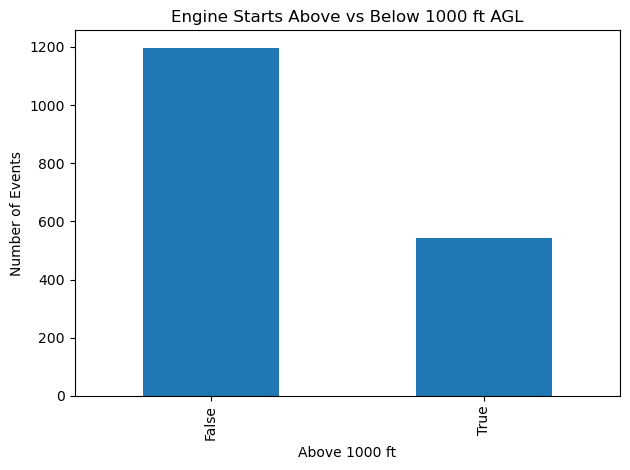

In [55]:
import matplotlib.pyplot as plt

df["Engine_Start_Above_1000ft"].value_counts().plot(kind="bar")

plt.title("Engine Starts Above vs Below 1000 ft AGL")
plt.ylabel("Number of Events")
plt.xlabel("Above 1000 ft")
plt.tight_layout()

plt.show()

### Interpretation

Most engine-start events occurred below the 1000 ft threshold.

This result provides evidence that the sailplane community does not consistently follow manufacturer recommendations.

# Distribution of Engine Start Altitudes

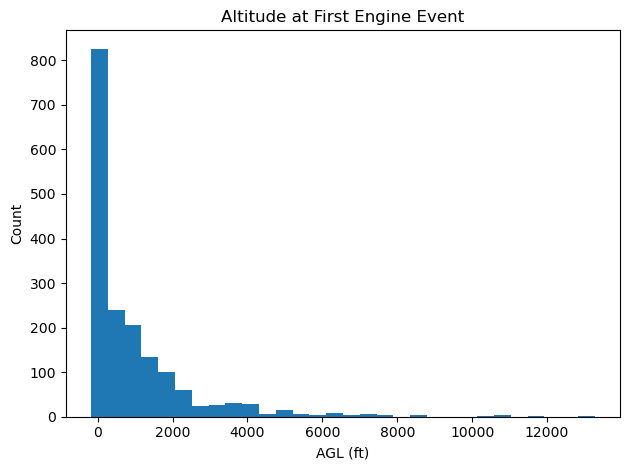

In [56]:
plt.hist(
    df["dynamic_AGL_at_first_engine_event (ft)"],
    bins=30
)

plt.title("Altitude at First Engine Event")
plt.xlabel("AGL (ft)")
plt.ylabel("Count")
plt.tight_layout()

plt.show()

### Interpretation

The altitude distribution is highly right-skewed.

Most engine starts occur relatively close to the ground, while only a small number occur at very high altitudes.

# Flight Outcome Analysis

This section evaluates landing outcomes after engine-start events.

In [57]:
df["Landing"].value_counts(normalize=True) * 100

Landing
HOME    94.367816
LOUT     5.632184
Name: proportion, dtype: float64

### Finding

94.4% of flights successfully returned HOME.

Only 5.6% resulted in an outlanding (LOUT).

This suggests that engine deployment is generally associated with successful recovery.

# Landing Outcome by Engine Start Altitude

In [58]:
pd.crosstab(
    df["Engine_Start_Above_1000ft"],
    df["Landing"],
    margins=True
)

Landing,HOME,LOUT,All
Engine_Start_Above_1000ft,,,
False,1143,54,1197
True,499,44,543
All,1642,98,1740


### Interpretation

Landing success rates remain high regardless of deployment altitude.

Additional variables beyond altitude may contribute to unsuccessful outcomes.

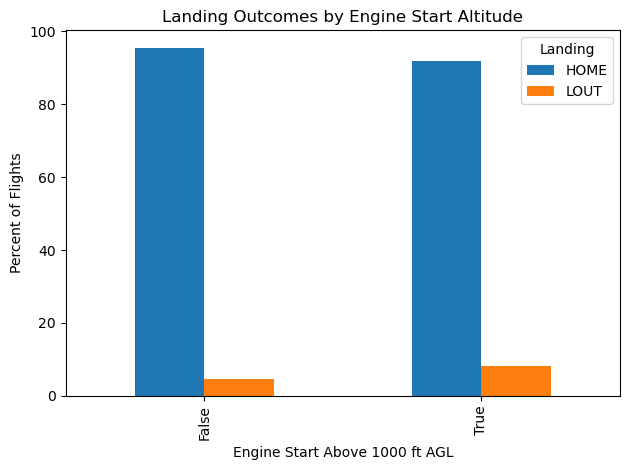

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

landing_rates = pd.crosstab(
    df["Engine_Start_Above_1000ft"],
    df["Landing"],
    normalize="index"
) * 100

landing_rates.plot(kind="bar")

plt.title("Landing Outcomes by Engine Start Altitude")
plt.ylabel("Percent of Flights")
plt.xlabel("Engine Start Above 1000 ft AGL")
plt.tight_layout()

plt.show()

# Engine Detection Sensor Analysis

In [60]:
df["event_sensor"].value_counts()

event_sensor
ENL    1545
MOP     168
RPM      27
Name: count, dtype: int64

In [61]:
df["event_sensor"].value_counts(normalize=True) * 100

event_sensor
ENL    88.793103
MOP     9.655172
RPM     1.551724
Name: proportion, dtype: float64

### Finding

ENL detected 88.8% of engine-start events.

MOP and RPM accounted for a much smaller proportion of detections.

ENL appears to be the most informative sensor for identifying engine activity.

# Visualization:
# Sensor Distribution

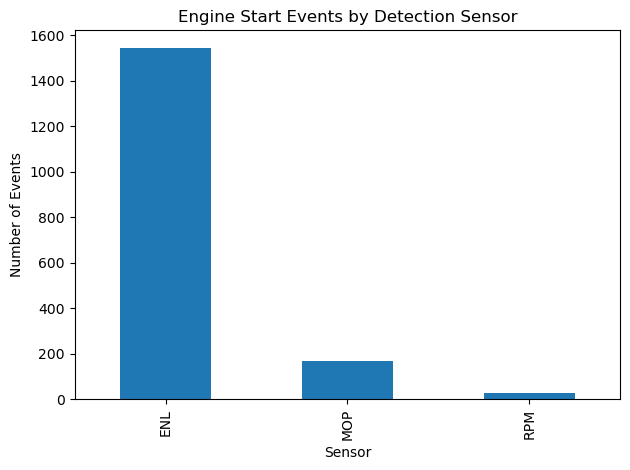

In [62]:
import matplotlib.pyplot as plt

df["event_sensor"].value_counts().plot(kind="bar")

plt.title("Engine Start Events by Detection Sensor")
plt.xlabel("Sensor")
plt.ylabel("Number of Events")

plt.tight_layout()
plt.show()

# Terrain Analysis

This section evaluates terrain characteristics at the first detected engine event.

In [63]:
df["terrain_label_at_first_engine_event"].value_counts().head(15)

terrain_label_at_first_engine_event
Herbaceous vegetation                  609
Open Forest, Other                     276
Shrubs                                 254
Agriculture                            203
Closed Forest, Other                   106
Closed Forest, Deciduous Broadleaf      94
Closed Forest, Evergreen Needleleaf     90
Bare/Sparse vegetation                  60
Urban                                   32
Wetland                                  7
Water Bodies                             5
Open Forest, Evergreen Needleleaf        2
Closed Forest, Mixed                     1
Open Forest, Deciduous Broadleaf         1
Name: count, dtype: int64

### Finding

Herbaceous vegetation represented the most common terrain type at engine-start events.

Open forest, shrubs, and agricultural terrain were also frequently observed.

In [64]:
df["terrain_label_at_first_engine_event"].value_counts(normalize=True).head(15) * 100

terrain_label_at_first_engine_event
Herbaceous vegetation                  35.000000
Open Forest, Other                     15.862069
Shrubs                                 14.597701
Agriculture                            11.666667
Closed Forest, Other                    6.091954
Closed Forest, Deciduous Broadleaf      5.402299
Closed Forest, Evergreen Needleleaf     5.172414
Bare/Sparse vegetation                  3.448276
Urban                                   1.839080
Wetland                                 0.402299
Water Bodies                            0.287356
Open Forest, Evergreen Needleleaf       0.114943
Closed Forest, Mixed                    0.057471
Open Forest, Deciduous Broadleaf        0.057471
Name: proportion, dtype: float64

# Visualization:
# Terrain Distribution

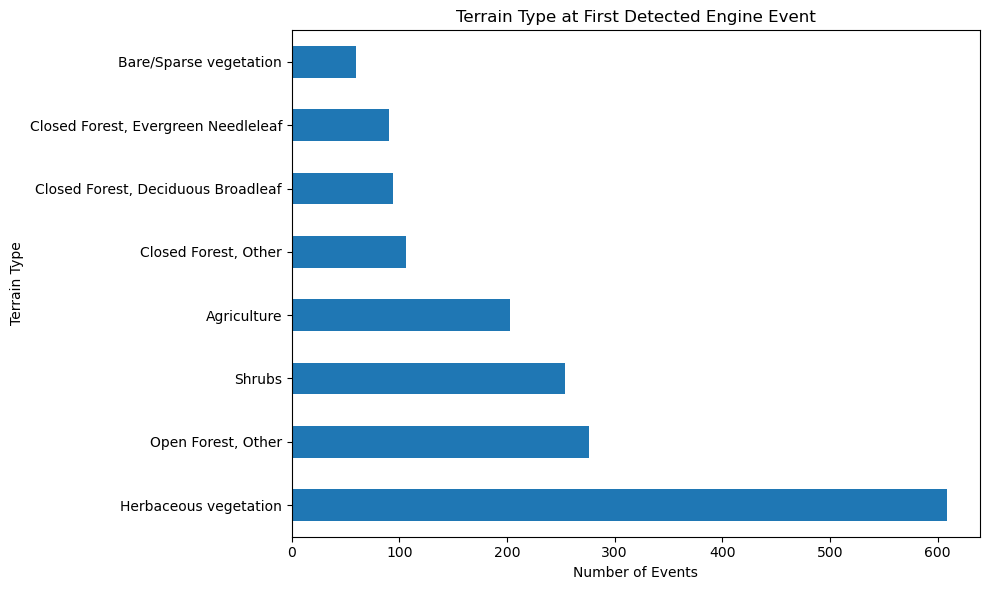

In [65]:
terrain_counts = (
    df["terrain_label_at_first_engine_event"]
    .value_counts()
    .head(8)
)

terrain_counts.plot(
    kind="barh",
    figsize=(10,6),
    title="Terrain Type at First Detected Engine Event"
)

plt.xlabel("Number of Events")
plt.ylabel("Terrain Type")
plt.tight_layout()
plt.show()

# Executive Dashboard

This dashboard summarizes the primary findings from the exploratory analysis.

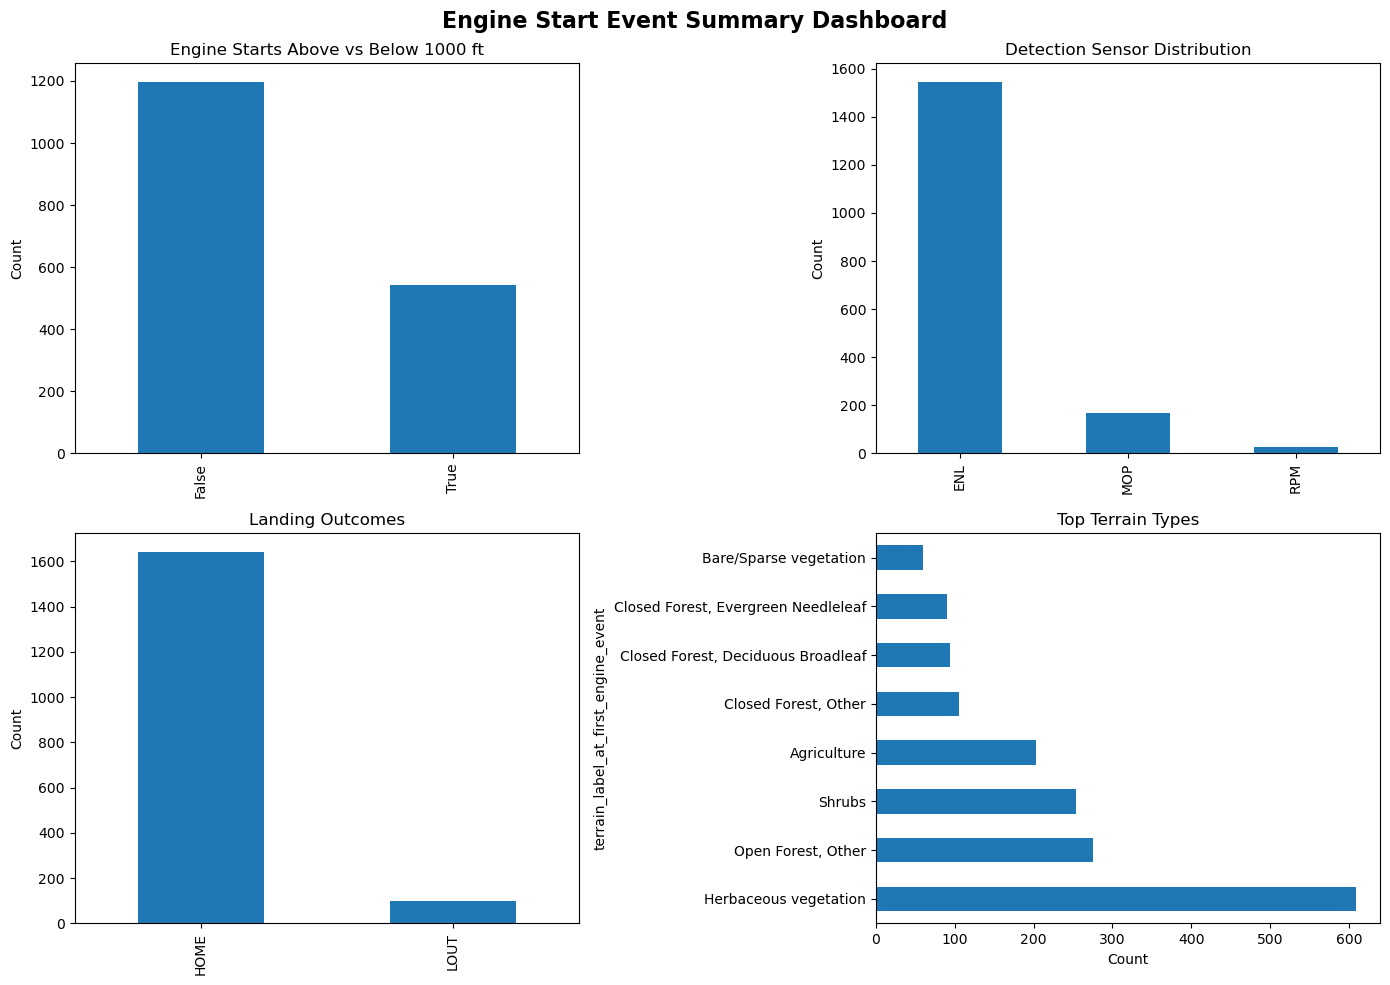

<Figure size 640x480 with 0 Axes>

In [73]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Engine Start Altitude
df["Engine_Start_Above_1000ft"].value_counts().plot(
    kind="bar",
    ax=axes[0,0],
    title="Engine Starts Above vs Below 1000 ft"
)
axes[0,0].set_xlabel("")
axes[0,0].set_ylabel("Count")

# 2. Sensor Distribution
df["event_sensor"].value_counts().plot(
    kind="bar",
    ax=axes[0,1],
    title="Detection Sensor Distribution"
)
axes[0,1].set_xlabel("")
axes[0,1].set_ylabel("Count")

# 3. Landing Outcome
df["Landing"].value_counts().plot(
    kind="bar",
    ax=axes[1,0],
    title="Landing Outcomes"
)
axes[1,0].set_xlabel("")
axes[1,0].set_ylabel("Count")

# 4. Terrain Profile
df["terrain_label_at_first_engine_event"].value_counts().head(8).plot(
    kind="barh",
    ax=axes[1,1],
    title="Top Terrain Types"
)
axes[1,1].set_xlabel("Count")

plt.suptitle(
    "Engine Start Event Summary Dashboard",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

plt.tight_layout()

plt.savefig(
    "../reports/engine_start_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Key Findings

1. 68.8% of engine starts occurred below 1000 ft AGL.

2. Most flights (94.4%) successfully returned home after engine deployment.

3. ENL was responsible for nearly 89% of engine-start detections.

4. Herbaceous vegetation and open forest terrain were the most common environments associated with engine-start events.

5. Altitude, landing outcome, terrain, and sensor measurements appear to be promising variables for future classification modeling.

## Conclusion

The exploratory analysis suggests that engine-start behavior can be characterized using a combination of altitude, terrain, flight outcome, and sensor information.

These findings provide the foundation for the confidence-based engine-start classification model developed in Notebook 02.

# Recommendations

Based on the exploratory analysis:

1. Investigate why most engine starts occur below 1000 ft AGL.

2. Use altitude, terrain, sensor information, and flight outcomes as candidate variables in predictive models.

3. Prioritize high-confidence engine-start events for future validation.

4. Continue development of the confidence-based classification framework described in Notebook 02.